# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from pathlib import Path

# Etapa 1

Foram coletadas 6 imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

IMG_0301.JPG: 4032x3024 -> 1008x756
IMG_0302.JPG: 4032x3024 -> 1008x756
IMG_0303.JPG: 4032x3024 -> 1008x756
IMG_0304.JPG: 4032x3024 -> 1008x756
IMG_0305.JPG: 4032x3024 -> 1008x756
IMG_0306.JPG: 4032x3024 -> 1008x756
IMG_0307.JPG: 4032x3024 -> 1008x756


## Carregregamento das imagens

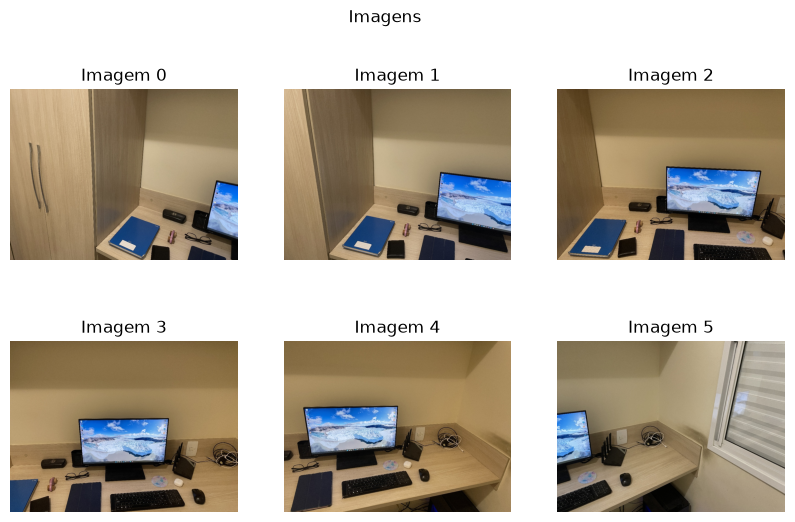

In [3]:
from src.visualization import plot_image_grid

images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

# random.shuffle(images)
plot_image_grid(images)

## Panorama do OpenCV

Este é o panorama criado utilizando a implementação nativa do OpenCV, apenas para critério de comparação.

Status: 0
Panorama do OpenCV
Tamanho: (810, 2242, 3)


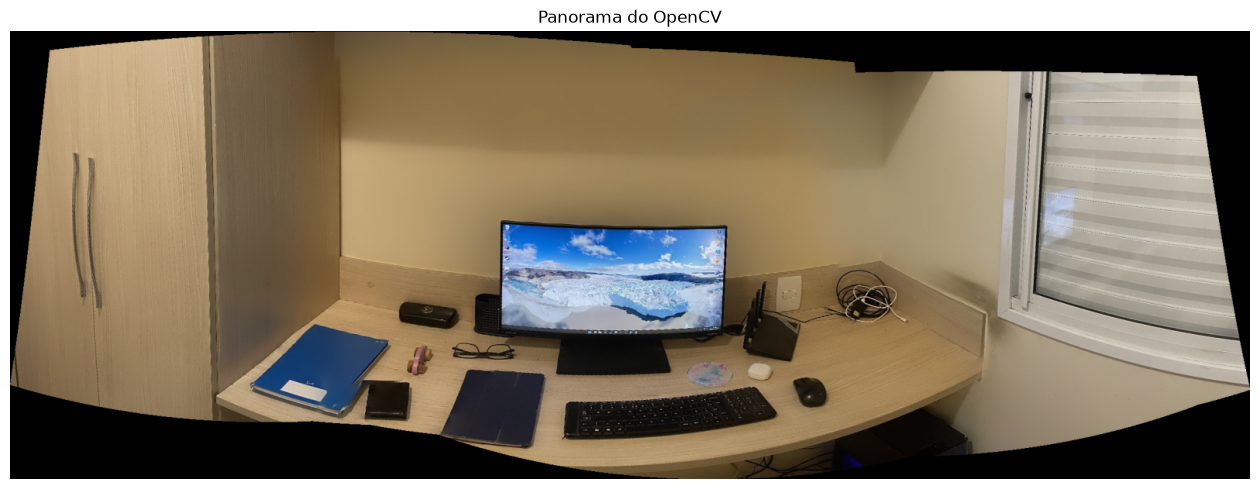

In [4]:
from src.visualization import plot_image

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

status, panorama_opencv = stitcher.stitch(images)

print("Status:", status)

if status == cv2.Stitcher_OK:
    print("Panorama do OpenCV")
    print("Tamanho:", panorama_opencv.shape)

    plot_image(panorama_opencv, "Panorama do OpenCV")

    cv2.imwrite(
        "results/panorama_opencv.jpg",
        panorama_opencv
    )

else:
    print("O Stitcher falhou.")

# Etapa 2

Detecção de keypoints com SIFT e ORB

Detector: sift
Número de keypoints: 476
Formato dos descritores: (476, 128)
Número de keypoints: 820
Formato dos descritores: (820, 128)
Número de keypoints: 899
Formato dos descritores: (899, 128)
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Número de keypoints: 754
Formato dos descritores: (754, 128)
Número de keypoints: 535
Formato dos descritores: (535, 128)


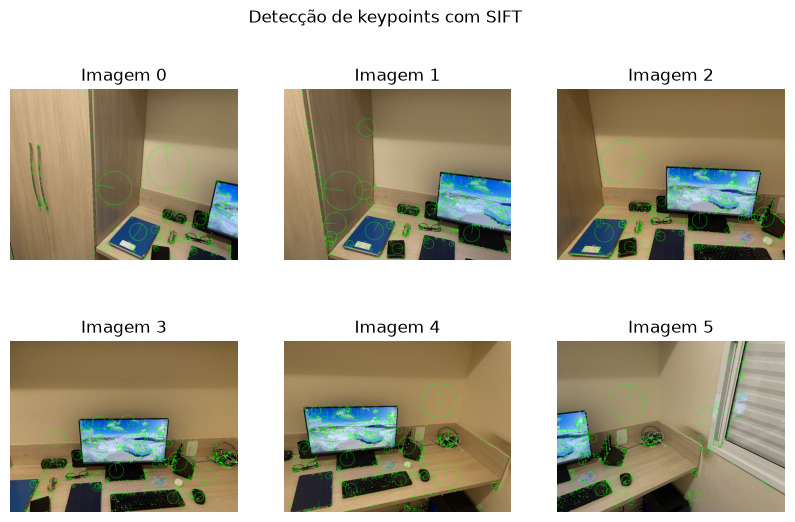

In [5]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

Detector: orb
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)


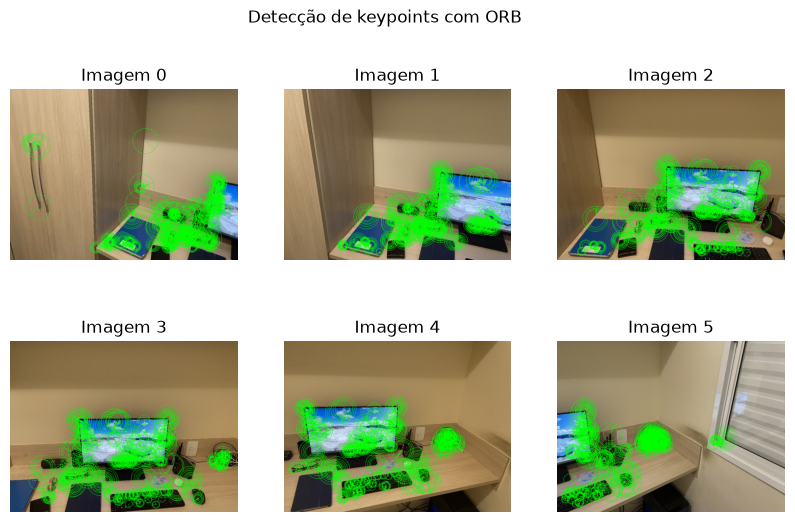

In [6]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

In [7]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.75

# match_all_images retorna dois dicionários. A estrutura do dicionário é 
# { (i, j): matches } onde i e j são índices de imagem, e matches é uma lista de matches.
# i sempre é menor que j.
matches_dict, lowe_matches_dict = match_all_images(
    [item["descriptors"] for item in images_sift], # extrai "descriptors" de cada item no array
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Sem o teste de Lowe")
for (i, j), matches in matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

print("Com o teste de Lowe")
for (i, j), matches in lowe_matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

Sem o teste de Lowe
Imagem 0 <-> Imagem 1: 476 matches
Imagem 0 <-> Imagem 2: 476 matches
Imagem 0 <-> Imagem 3: 476 matches
Imagem 0 <-> Imagem 4: 476 matches
Imagem 0 <-> Imagem 5: 476 matches
Imagem 0 <-> Imagem 6: 476 matches
Imagem 1 <-> Imagem 2: 820 matches
Imagem 1 <-> Imagem 3: 820 matches
Imagem 1 <-> Imagem 4: 820 matches
Imagem 1 <-> Imagem 5: 820 matches
Imagem 1 <-> Imagem 6: 820 matches
Imagem 2 <-> Imagem 3: 899 matches
Imagem 2 <-> Imagem 4: 899 matches
Imagem 2 <-> Imagem 5: 899 matches
Imagem 2 <-> Imagem 6: 899 matches
Imagem 3 <-> Imagem 4: 1004 matches
Imagem 3 <-> Imagem 5: 1004 matches
Imagem 3 <-> Imagem 6: 1004 matches
Imagem 4 <-> Imagem 5: 1142 matches
Imagem 4 <-> Imagem 6: 1142 matches
Imagem 5 <-> Imagem 6: 754 matches
Com o teste de Lowe
Imagem 0 <-> Imagem 1: 150 matches
Imagem 0 <-> Imagem 2: 104 matches
Imagem 0 <-> Imagem 3: 95 matches
Imagem 0 <-> Imagem 4: 88 matches
Imagem 0 <-> Imagem 5: 15 matches
Imagem 0 <-> Imagem 6: 23 matches
Imagem 1 <-> I

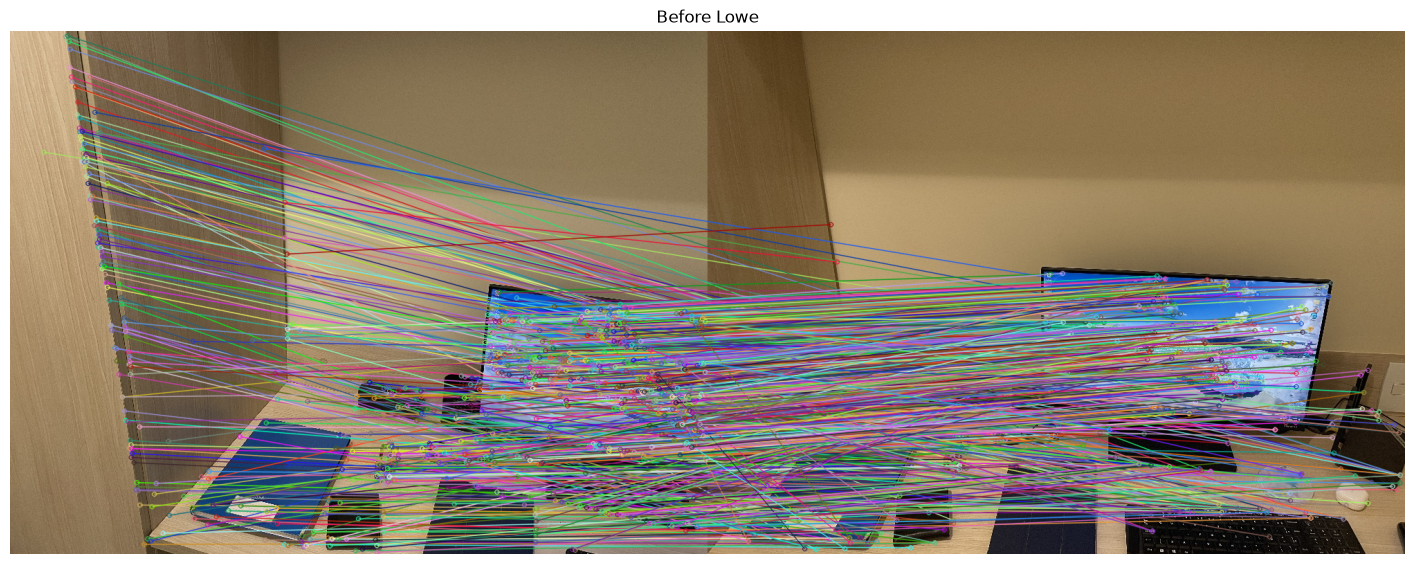

In [8]:
from src.visualization import plot_matches

i = 1
j = 2

plot_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            matches_dict[(i, j)], # matches associados ao par de imagens
            "Before Lowe")

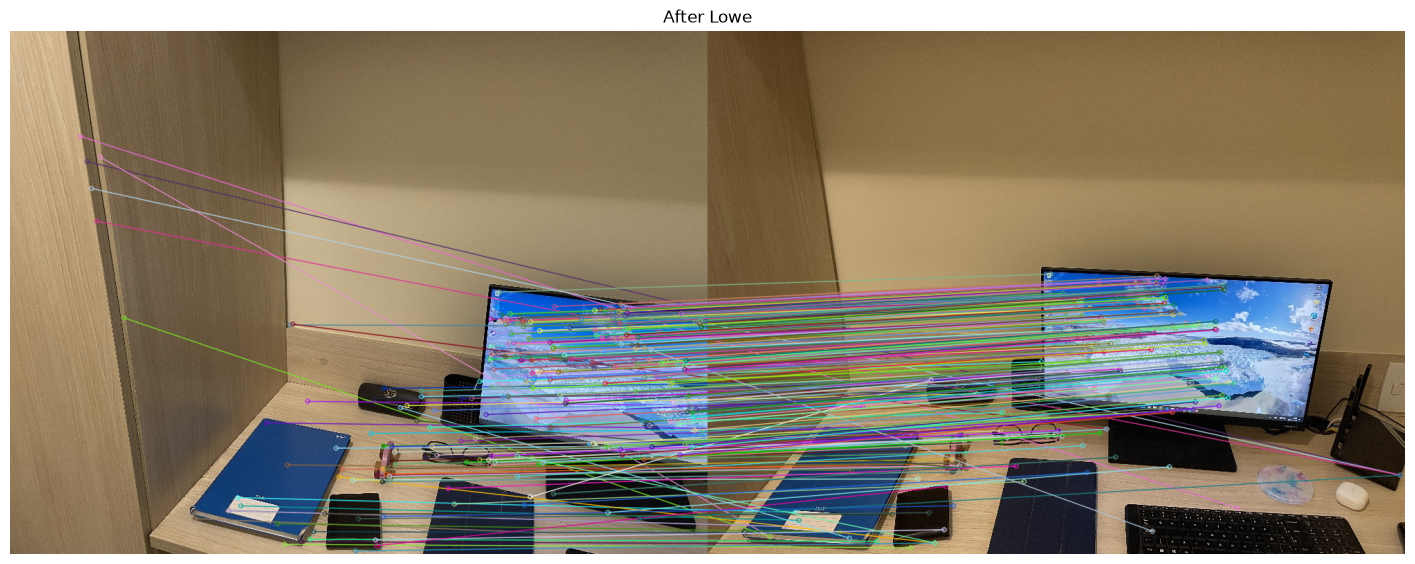

In [9]:
plot_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            lowe_matches_dict[(i, j)], # matches associados ao par de imagens, filtrados com teste da razão
            "After Lowe")

# Etapa 4

Ordenação automática

In [10]:
from src.ordering import build_connectivity_matrix, build_graph

connectivity_matrix = build_connectivity_matrix(lowe_matches_dict)

print(connectivity_matrix)

graph = build_graph(
    connectivity_matrix,
    min_matches=20
)

print(graph)

[[  0 150 104  95  88  15  23]
 [150   0 257 204 203  25  17]
 [104 257   0 303 299 102  17]
 [ 95 204 303   0 396 119  43]
 [ 88 203 299 396   0 168  59]
 [ 15  25 102 119 168   0 132]
 [ 23  17  17  43  59 132   0]]
{0: [1, 2, 3, 4, 6], 1: [0, 2, 3, 4, 5], 2: [0, 1, 3, 4, 5], 3: [0, 1, 2, 4, 5, 6], 4: [0, 1, 2, 3, 5, 6], 5: [1, 2, 3, 4, 6], 6: [0, 3, 4, 5]}


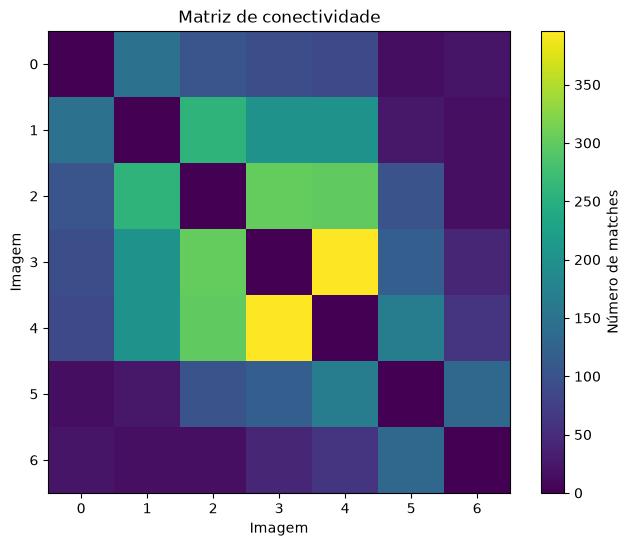

In [11]:
from src.visualization import plot_matrix

plot_matrix(connectivity_matrix)

# Etapa 5

Homografia e Alinhamento

In [12]:
from src.homography import estimate_homography

homographies = {}
inlier_masks = {}

for i in range(len(images) - 1):

    pair = (i, i + 1)

    pair_matches = lowe_matches_dict[pair]

    print(f"\n===== PAR {i} -> {i+1} =====")
    print("Matches Lowe:", len(pair_matches))

    H, inlier_mask = estimate_homography(
        images_sift[i]["keypoints"],
        images_sift[i + 1]["keypoints"],
        pair_matches
    )

    homographies[pair] = H
    inlier_masks[pair] = inlier_mask

    n_inliers = int(inlier_mask.sum())

    if len(pair_matches) > 0:
        inlier_rate = n_inliers / len(pair_matches)
    else:
        inlier_rate = 0.0

    print("Inliers:", n_inliers)
    print("Inlier rate:", f"{inlier_rate:.2%}")
    print("H:")
    print(H)


===== PAR 0 -> 1 =====
Matches Lowe: 150
Inliers: 130
Inlier rate: 86.67%
H:
[[ 1.19339646e+00 -1.23341493e-02 -2.38555669e+02]
 [ 1.98676924e-02  9.99904550e-01  2.79375210e+01]
 [ 3.04104607e-04 -1.50866977e-04  1.00000000e+00]]

===== PAR 1 -> 2 =====
Matches Lowe: 257
Inliers: 201
Inlier rate: 78.21%
H:
[[ 1.24079237e+00  3.85720776e-02 -3.00418652e+02]
 [ 2.92848776e-02  1.06208599e+00 -2.35915627e+00]
 [ 3.26654149e-04 -1.07294298e-04  1.00000000e+00]]

===== PAR 2 -> 3 =====
Matches Lowe: 303
Inliers: 271
Inlier rate: 89.44%
H:
[[ 1.30925404e+00  7.32546786e-02 -3.06447626e+02]
 [ 4.70659338e-02  1.16752112e+00 -2.57660818e+01]
 [ 3.22319159e-04 -1.96578831e-05  1.00000000e+00]]

===== PAR 3 -> 4 =====
Matches Lowe: 396
Inliers: 361
Inlier rate: 91.16%
H:
[[ 1.40741575e+00  8.78620688e-02 -3.56627069e+02]
 [ 1.00537845e-01  1.28374562e+00 -1.35199074e+02]
 [ 3.74522403e-04  1.18634065e-04  1.00000000e+00]]

===== PAR 4 -> 5 =====
Matches Lowe: 168
Inliers: 96
Inlier rate: 57.14

# Etapa 6: Composição, blending, deghosting

In [13]:
from src.composition import compute_global_transforms

reference = len(images) // 2

print("Imagem de referência:", reference)

global_transforms = compute_global_transforms(
    homographies,
    len(images),
    reference
)

Imagem de referência: 3


In [14]:
for i, H in enumerate(global_transforms):

    print(f"\nImagem {i} -> referência")

    print(H)


Imagem 0 -> referência
[[ 1.61213159e+00  2.47937906e-01 -1.05961013e+03]
 [ 1.12205966e-01  1.24986678e+00 -2.79692190e+01]
 [ 1.13878988e-03 -2.60949225e-04  7.26788484e-01]]

Imagem 1 -> referência
[[ 1.52655529e+00  1.61183499e-01 -6.99944779e+02]
 [ 8.41731668e-02  1.24458781e+00 -4.26599309e+01]
 [ 7.26009623e-04 -1.15740140e-04  9.03215689e-01]]

Imagem 2 -> referência
[[ 1.30925404e+00  7.32546786e-02 -3.06447626e+02]
 [ 4.70659338e-02  1.16752112e+00 -2.57660818e+01]
 [ 3.22319159e-04 -1.96578831e-05  1.00000000e+00]]

Imagem 3 -> referência
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Imagem 4 -> referência
[[ 6.55376288e-01 -6.56342896e-02  2.24851230e+02]
 [-7.62242713e-02  7.76991775e-01  7.78649297e+01]
 [-2.36410307e-04 -6.75961808e-05  9.06550744e-01]]

Imagem 5 -> referência
[[ 2.19032752e-01 -8.91381362e-02  4.05179568e+02]
 [-6.51564541e-02  5.55000243e-01  3.55291987e+01]
 [-3.55246528e-04  4.08130774e-05  6.11858453e-01]]

Imagem 6 -> referência
[[ 7.73324584e-02 -8.0383

In [19]:
from src.composition import compose_panorama, crop_panorama

panorama, panorama_mask = compose_panorama(images, global_transforms)
panorama_crop = crop_panorama(panorama, panorama_mask)
print("Panorama crop:", panorama_crop.shape)

Canvas do panorama: 5971 x 2469
Processando imagem 1/7...
Processando imagem 2/7...
Processando imagem 3/7...
Processando imagem 4/7...
Processando imagem 5/7...
Processando imagem 6/7...
Processando imagem 7/7...
Panorama crop: (785, 4987, 3)


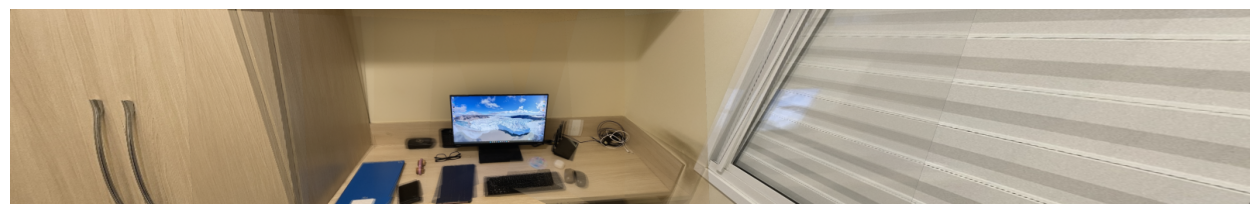

In [20]:
plot_image(panorama_crop)